# ECG_LSTM


## Imports

In [2]:
import numpy as np
import pandas as pd 
import matplotlib as mp
import sklearn as sk
import matplotlib.pyplot as plt
import seaborn as sns
import wfdb
import ast
import utility_functions as utility
import torch
import time 

In [3]:
import importlib
#Reloads my utility module (is used after updating its methods)
importlib.reload(utility)

<module 'utility_functions' from 'C:\\Users\\algot\\ML_python\\assignment2\\utility_functions.py'>

## Load Data

Loads in data

In [ ]:
path = ''   #Changable paths
sampling_rate=100

# loading and converting annotation data
Y = pd.read_csv(path+'ptbxl_database.csv', index_col='ecg_id')
Y.scp_codes = Y.scp_codes.apply(lambda x: ast.literal_eval(x))

In [ ]:
# Loading raw signal data
X = utility.load_raw_data(Y, sampling_rate, path)

# Loading scp_statements.csv for diagnostic aggregation
agg_df = pd.read_csv(path+'scp_statements.csv', index_col=0)
agg_df = agg_df[agg_df.diagnostic == 1]

In [ ]:
# Applying diagnostic superclass
Y['diagnostic_superclass'] = Y.scp_codes.apply(lambda x: utility.aggregate_diagnostic(x, agg_df))

In [ ]:
#printing no of empty lists
num_empty_lists = Y['diagnostic_superclass'].apply(lambda x: len(x) == 0).sum()
total_elements = Y['diagnostic_superclass'].apply(lambda x: len(x) >= 0).sum()
print("no of empty lists:",num_empty_lists)
print("percent of empty lists in relation to all lists:",num_empty_lists*100/total_elements, "%")

nr of empty lists: 407
percent of empty lists in relation to all lists: 1.8638091312909282 %


In [8]:
# Remove rows with empty 'diagnostic_superclass' lists from Y
Y_filtered = Y[Y['diagnostic_superclass'].apply(lambda x: len(x) > 0)]
Y_filtered  = Y_filtered.reset_index(drop=True)

In [ ]:
# Loading raw signal data corresponding to filtered Y values.
X_filtered = utility.load_raw_data(Y_filtered, sampling_rate, path)

# Loading scp_statements.csv for diagnostic aggregation
agg_df = pd.read_csv(path+'scp_statements.csv', index_col=0)
agg_df = agg_df[agg_df.diagnostic == 1]
#alternatively, convert X to df, then remove 
#corresponding entries through indexes from filtered_y, then convert back to numpy array

In [10]:
#checking that X and Y are the same length after filtering:

if len(Y_filtered) == len(X_filtered):
    print("The filtered datasets have the same length.")

The filtered datasets have the same length.


In [11]:
#reducing data in X
X_small = X_filtered[:, :200, :,]

In [ ]:
#copies of X,Y
Y_copy = Y_filtered.copy()
X_copy = X_small.copy()

In [ ]:
# reset the index
Y_copy.reset_index(drop=True, inplace=True)

In [ ]:
#tabular data for merging with X
y_tab = Y_copy.copy() 

In [154]:
Y_copy.diagnostic_superclass.value_counts()

diagnostic_superclass
[NORM]                 9083
[MI]                   2538
[STTC]                 2406
[CD]                   1709
[MI, CD]               1302
[HYP, STTC]             783
[MI, STTC]              602
[HYP]                   536
[CD, STTC]              472
[CD, NORM]              407
[MI, HYP, STTC]         362
[CD, HYP]               238
[MI, CD, STTC]          223
[MI, HYP]               183
[HYP, STTC, CD]         113
[MI, HYP, STTC, CD]     104
[MI, CD, HYP]            98
[CD, STTC, HYP]          98
[HYP, CD]                62
[MI, CD, STTC, HYP]      54
[STTC, NORM]             28
[MI, HYP, CD]            19
[CD, NORM, STTC]          5
[CD, NORM, HYP]           2
[HYP, NORM]               2
[MI, CD, NORM, HYP]       1
Name: count, dtype: int64

## Encode Y

In [14]:
from sklearn.preprocessing import MultiLabelBinarizer

# (Y_copy.diagnostic_superclass contains the lists of labels)

# Flatten the list of labels and remove duplicates
all_labels = set(label for sublist in Y_copy.diagnostic_superclass for label in sublist)

# Initialize MultiLabelBinarizer
mlb = MultiLabelBinarizer(classes=sorted(all_labels))

# Fit and transform the labels to one-hot encoded format
# Note: This step automatically removes empty lists and treats them as samples with no labels
Y_encoded = mlb.fit_transform(Y_copy.diagnostic_superclass)

# Convert the encoded labels back to a DataFrame for easier handling
Y_encoded_df = pd.DataFrame(Y_encoded, columns=mlb.classes_, index=Y_copy.index)

# Now, Y_encoded_df is a DataFrame where each column represents a unique label (diagnostic_superclass)
# and each row has binary indicators for the presence of each label.

#reset index for Y_encoded_df
Y_encoded_df = Y_encoded_df.reset_index(drop=True) #is never used

## Data Cleaning for tabular data

In [164]:
y_tab

,patient_id,age,sex,height,weight,nurse,site,device,recording_date,report,...,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr,diagnostic_superclass
0,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,sinusrhythmus periphere niederspannung,...,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr,[NORM]
1,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,sinusbradykardie sonst normales ekg,...,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr,[NORM]
2,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,sinusrhythmus normales ekg,...,NaN,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr,[NORM]
3,17014.0,24.0,0,NaN,82.0,2.0,0.0,CS-12 E,1984-11-15 13:44:57,sinusrhythmus normales ekg,...,", II,III,AVF",NaN,NaN,NaN,NaN,NaN,3,records100/00000/00004_lr,records500/00000/00004_hr,[NORM]
4,17448.0,19.0,1,NaN,70.0,2.0,0.0,CS-12 E,1984-11-17 10:43:15,sinusrhythmus normales ekg,...,", III,AVR,AVF",NaN,NaN,NaN,NaN,NaN,4,records100/00000/00005_lr,records500/00000/00005_hr,[NORM]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21425,17180.0,67.0,1,NaN,NaN,1.0,2.0,AT-60 3,2001-05-31 09:14:35,ventrikulÄre extrasystole(n) sinustachykardie ...,...,NaN,", alles,",NaN,NaN,1ES,NaN,7,records100/21000/21833_lr,records500/21000/21833_hr,[STTC]
21426,20703.0,93.0,0,NaN,NaN,1.0,2.0,AT-60 3,2001-06-05 11:33:39,sinusrhythmus lagetyp normal qrs(t) abnorm ...,...,NaN,NaN,NaN,NaN,NaN,NaN,4,records100/21000/21834_lr,records500/21000/21834_hr,[NORM]
21427,19311.0,59.0,1,NaN,NaN,1.0,2.0,AT-60 3,2001-06-08 10:30:27,sinusrhythmus lagetyp normal t abnorm in anter...,...,NaN,", I-AVR,",NaN,NaN,NaN,NaN,2,records100/21000/21835_lr,records500/21000/21835_hr,[STTC]
21428,8873.0,64.0,1,NaN,NaN,1.0,2.0,AT-60 3,2001-06-09 18:21:49,supraventrikulÄre extrasystole(n) sinusrhythmu...,...,NaN,NaN,NaN,NaN,SVES,NaN,8,records100/21000/21836_lr,records500/21000/21836_hr,[NORM]


In [206]:

#show null values for y_tab

null_counts = y_tab.isnull().sum()

# Calculate the percentage of total values that are null for each column
null_percentage = (y_tab.isnull().sum() / len(y_tab)) * 100

# Combine the counts and percentages into a single DataFrame for a clearer view
null_stats = pd.DataFrame({'Null Counts': null_counts, 'Percentage': null_percentage})

# Display the stats
print(null_stats)

            Null Counts  Percentage
age                  85    0.396640
sex                   0    0.000000
height            14503   67.676155
weight            12056   56.257583
site                 17    0.079328
device                0    0.000000
heart_axis            0    0.000000


In [171]:

y_tab = y_tab.drop(['infarction_stadium1', 'infarction_stadium2','baseline_drift',
                   'burst_noise', 'electrodes_problems', 'extra_beats', 
                    'pacemaker', 'filename_lr', 'filename_hr',  'diagnostic_superclass',
                   'patient_id', 'static_noise', 'scp_codes', 'report',
                   'strat_fold'], axis=1)

In [189]:
#dropping columns
y_tab = y_tab.drop(['recording_date','nurse', 'validated_by'], axis=1)
y_tab = y_tab.drop(['second_opinion','initial_autogenerated_report', 'validated_by_human'], axis=1)

In [190]:
y_tab.dtypes
#for column in y_tab.columns:
#    print(f"Unique values in '{column}': {y_tab[column].unique()}")

age           float64
sex             int64
height        float64
weight        float64
site          float64
device         object
heart_axis     object
dtype: object

In [193]:
from sklearn.preprocessing import LabelEncoder
#encode columns with object type in y_tab and save it to y_tab2

y_tab2=y_tab.copy()
# Initialize the encoder
encoder = LabelEncoder()
# Apply the encoder to the 'device' column
y_tab2['device'] = encoder.fit_transform(y_tab['device'])
#save the mapping or the encoder itself for inverse transforming or future use
device_mapping = {index: label for index, label in enumerate(encoder.classes_)}

# Apply the encoder to the 'heart_axis' column
y_tab2['heart_axis'] = encoder.fit_transform(y_tab['heart_axis'])
heart_axis_mapping = {index: label for index, label in enumerate(encoder.classes_)}


In [194]:
y_tab2.dtypes

age           float64
sex             int64
height        float64
weight        float64
site          float64
device          int32
heart_axis      int32
dtype: object

In [204]:
#convert floats to int, but keep all Null values (for imputation)
placeholder = -1 
y_tab2['age'] = y_tab2['age'].replace(placeholder, pd.NA).astype('Int64')
y_tab2['height'] = y_tab2['height'].replace(placeholder, pd.NA).astype('Int64')
y_tab2['weight'] = y_tab2['weight'].replace(placeholder, pd.NA).astype('Int64')
y_tab2['site'] = y_tab2['site'].replace(placeholder, pd.NA).astype('Int64')


In [205]:
y_tab2.dtypes

age           Int64
sex           int32
height        Int64
weight        Int64
site          Int64
device        int32
heart_axis    int32
dtype: object

use imputator to find height, and weight, and age 

In [209]:
from sklearn.impute import KNNImputer

# Initialize the imputer
imputer = KNNImputer(n_neighbors=5) 

# Fit the imputer and transform y_tab to fill in missing values
y_tab_imputed = imputer.fit_transform(y_tab2)

# in order to get the dataframe (not neccesary)
y_tab_imputed_df = pd.DataFrame(y_tab_imputed, columns=y_tab2.columns, index=y_tab2.index)


In [211]:

#show null values for y_tab_imputed_df

null_counts = y_tab_imputed_df.isnull().sum()

# Calculate the percentage of total values that are null for each column
null_percentage = (y_tab_imputed_df.isnull().sum() / len(y_tab)) * 100

# Combine the counts and percentages into a single DataFrame for a clearer view
null_stats = pd.DataFrame({'Null Counts': null_counts, 'Percentage': null_percentage})

# Display the stats
print(null_stats)

            Null Counts  Percentage
age                   0         0.0
sex                   0         0.0
height                0         0.0
weight                0         0.0
site                  0         0.0
device                0         0.0
heart_axis            0         0.0


checking validity of imputed values:
they have similar distribution for age which is a good sign

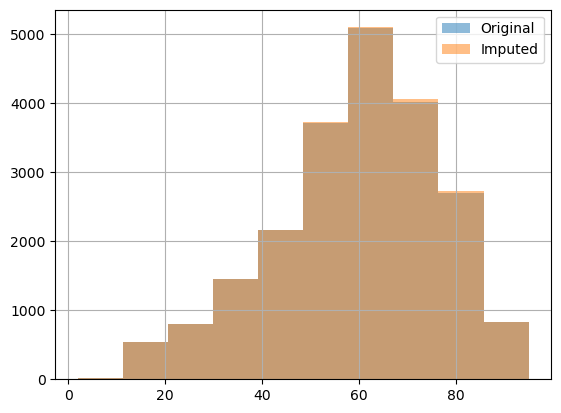

In [213]:
y_tab2['age'].dropna().hist(alpha=0.5, label='Original')
y_tab_imputed_df['age'].hist(alpha=0.5, label='Imputed')
plt.legend()
plt.show()

In [219]:
# Find indices with any missing value in y_tab2
indices_with_missing_values = y_tab2[y_tab2.isnull().any(axis=1)].index
# Print the indices
print(indices_with_missing_values)

Index([    0,     1,     2,     3,     4,     5,     6,     7,     8,     9,
       ...
       21420, 21421, 21422, 21423, 21424, 21425, 21426, 21427, 21428, 21429],
      dtype='int64', length=14812)


using these indices to see the height and weight that the KNN has imputed.

In [ ]:
indices_with_missing_values= [21420, 21421, 21422, 21423, 21424, 21425, 21426, 21427, 21428, 21429]
print(y_tab2.loc[indices_with_missing_values])
print(y_tab_imputed_df.loc[indices_with_missing_values])

hmm, there seems to be quite a lot of varience of the imputed values. 
especially concering is the imputation of patients with both height and
weight missing at the same time. As it might be more inaccurate then. 
But normal distribution seemed fine.

## Normalize

In [ ]:
import numpy as np
#normalize X
# I need to compute the mean and std deviation across all samples

# Flatten the data to compute global mean and std dev (it's multidimensional per sample)
X_flattened = X_copy.reshape(-1, X_copy.shape[-1])  # Reshape to 2D if it's not already (keeps the last dimension intact)

mean = X_flattened.mean(axis=0)  # Compute mean for each channel/feature
std = X_flattened.std(axis=0)  # Compute std for each channel/feature

# Broadcast the mean and std to match the shape of X_copy for element-wise operations
X_normalized = (X_copy - mean) / std

# If std is 0 for some features (leading to division by zero), you can add a small epsilon for stability
epsilon = 1e-10
X_normalized = (X_copy - mean) / (std + epsilon)
X_copy= X_normalized


In [220]:
from sklearn.preprocessing import StandardScaler
#normalize tabular data in y.
# Initialize the scaler
scaler = StandardScaler()

# Fit the scaler to the data and transform it
y_tab_normalized = scaler.fit_transform(y_tab_imputed_df)

# Convert the normalized array back to a DataFrame (optional, but useful for keeping column names)
y_tab_normalized_df = pd.DataFrame(y_tab_normalized, columns=y_tab_imputed_df.columns, index=y_tab_imputed_df.index)


In [221]:
import numpy as np

# Assuming X_time_series is thr time series data of shape (num_samples, time_steps, num_features)
# and X_tabular is tabular data of shape (num_samples, num_tabular_features)

# Replicate tabular data to match time dimension
y_tabular_replicated = np.repeat(y_tab_normalized[:, np.newaxis, :], X_copy.shape[1], axis=1)

# Concatenate along the feature dimension
X_combined = np.concatenate((X_copy, y_tabular_replicated), axis=2)


In [251]:
#verify successful combination of time series and tabular data:

print("Shape of X_copy:", X_copy.shape)
print("Shape of y_tabular_replicated:", y_tabular_replicated.shape)
print("Shape of X_combined:", X_combined.shape)

# Calculate the expected number of features after concatenation
expected_num_features = X_copy.shape[2] + y_tab_normalized.shape[1]  # num_features_in_X_copy + num_features_in_y_tab_normalized

print("Expected number of features:", expected_num_features)

#It added the 12 features from X with the 7 features from Y tabular. Good.

Shape of X_copy: (21430, 200, 19)
Shape of y_tabular_replicated: (21430, 200, 7)
Shape of X_combined: (21430, 200, 19)
Expected number of features: 26


In [222]:
X_copy=X_combined.copy()

## test and validation sets

In [223]:
# reset the index to ensure it's continuous and starts from 0
#Y_copy.reset_index(drop=True, inplace=True)
#Y_encoded_df = Y_encoded_df.reset_index(drop=True) #is never used

split dataset

In [224]:
import numpy as np

# Split data into train, test, and validation
test_fold = 10
val_fold = 9

# Extract indices for validation, training, and test to ensure consistency
val_indices = np.where(Y_copy.strat_fold == val_fold)[0]
train_test_indices = np.where(Y_copy.strat_fold != val_fold)[0]
test_indices = np.where(Y_copy.strat_fold == test_fold)[0]
train_indices = np.where((Y_copy.strat_fold != val_fold) & (Y_copy.strat_fold != test_fold))[0]

# Validation set
X_val = X_copy[val_indices]
y_val = Y_encoded[val_indices]

# Train set
X_train = X_copy[train_indices]
y_train = Y_encoded[train_indices]

# Test set
X_test = X_copy[test_indices]
y_test = Y_encoded[test_indices]


In [225]:
#checking number of folds
num_folds = Y_copy['strat_fold'].nunique()
print("Number of folds:", num_folds)

Number of folds: 10


In [226]:
from torch.utils.data import Dataset, DataLoader
#prepare the data.
class ECGDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    #def __getitem__(self, idx):
    #    return torch.tensor(self.X[idx], dtype=torch.float), torch.tensor(self.y[idx], dtype=torch.long)
    def __getitem__(self, idx):
        X_tensor = torch.tensor(self.X[idx], dtype=torch.float)
        y_tensor = torch.tensor(self.y[idx], dtype=torch.float)  # Ensure labels are float
        return X_tensor, y_tensor

# Assuming y_train and y_test are already encoded as integers
train_dataset = ECGDataset(X_train, y_train)
test_dataset = ECGDataset(X_test, y_test)
val_dataset = ECGDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)  

## Training

Define the LSTM Model (IN USE)

In [227]:
import torch.nn as nn

#dropout introduces randomness in the activations during training, 
#which helps prevent overfitting by ensuring that the network does not 
#become too dependent on any single neuron
class SimpleLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout_rate=0.2):
        super(SimpleLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        # Define the LSTM layer
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout_rate if num_layers > 1 else 0.0)  # Dropout added only if num_layers > 1
        
        # Define the dropout layer
        self.dropout = nn.Dropout(dropout_rate)
        
        # Define the final, fully-connected output layer
        self.fc = nn.Linear(hidden_size, num_classes)
        #self.classifier = nn.Linear(hidden_size, num_classes) #Man kan också ha denna. fast hidden_dim istället för hidden_size
    
    def forward(self, x):
        # Initialize hidden and cell state
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        
        # Forward propagate LSTM
        out, _ = self.lstm(x, (h0, c0))
        
        # Apply dropout
        out = self.dropout(out)
        
        # Decode the hidden state of the last time step
        out = self.fc(out[:, -1, :])
        return out


#alternativ kod för forward:
        #def forward(self, x):
            # Get LSTM outputs (all hidden states, final hidden state, final cell state)
            #all_hidden_states, (final_hidden_state, final_cell_state) = self.lstm(x)
            # Apply dropout to the final hidden state
            #final_hidden_state = self.dropout(final_hidden_state) 
            # Use only the last layer of the hidden state 
            #out = self.classifier(final_hidden_state[-1])
            #out = torch.sigmoid(out)
            #return out

LSTM without dropout (NOT USED ANYMORE)

In [228]:
y_train_indices = np.argmax(y_train, axis=1) if y_train.ndim > 1 else y_train
y_test_indices = np.argmax(y_test, axis=1) if y_test.ndim > 1 else y_test

In [229]:
#CUDA test
#import torch
#print(torch.cuda.is_available())  # Should print True if CUDA is available
#print(torch.cuda.device_count())  # Prints the number of GPUs available
#print(torch.cuda.get_device_name(0))  # Prints the name of the GPU

In [230]:
from sklearn.utils.class_weight import compute_class_weight
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Assuming 'y_train' is a binary matrix of shape [n_samples, n_classes]
class_weights = []
for i in range(y_train.shape[1]):  # For each class
    # Compute class weight for class i
    weights = compute_class_weight(class_weight='balanced', classes=[0, 1], y=y_train[:, i])
    class_weights.append(weights[1])  # We're interested in the weight for the "positive" class

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)


In [231]:
#is used to validate a model during training
def validate(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
    avg_loss = total_loss / len(val_loader)
    return avg_loss

In [241]:
#training

from torch.optim.lr_scheduler import StepLR
from torch.optim.lr_scheduler import ReduceLROnPlateau

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

#The input_size=12 refers to the number of features each input sample has.
#input size is 12 without tabular data
#input size is 19 with tabular data.
model = SimpleLSTM(input_size=19, hidden_size=128, num_layers=2, num_classes=y_train.shape[1]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=class_weights) #using weights and BCEWithLogitsLoss 

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
# Define the scheduler
#scheduler = StepLR(optimizer, step_size=10, gamma=0.1)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5, verbose=True)

#timer for seeing how long each epoch takes
start_time = time.time()
total_epoch_time = 0  # Initialize total epoch time to calculate average later


#variables for early stopping
no_improvement_count = 0
best_val_loss = 5000 # a really high number
best_training_loss = 5000 # a really high number
patience = 10 # the number of loops before an improvement in validation loss is accepted.
train_loss_tolerance = 0.01  # Allow up to 1% increase in training loss


#lists to keep track of training and validation losses
training_losses = []
validation_losses =[]


# Training loop
num_epochs = 50
for epoch in range(num_epochs):
    epoch_start_time = time.time() #timer
    model.train()
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    val_loss = validate(model,val_loader, criterion, device)
    train_loss = loss.item()
    
    training_losses.append(loss.item())
    validation_losses.append(val_loss)
    
    scheduler.step(val_loss)
    # using early stopping and model saving in order to prevent overfitting
    if val_loss < best_val_loss and train_loss < best_training_loss:
        best_val_loss = val_loss
        train_loss = best_training_loss
        best_model_state = model.state_dict()  # Save the current model state
        best_epoch = epoch
        no_improvement_count = 0
    else:
        no_improvement_count += 1
    if no_improvement_count >= patience:
        print("Early stopping triggered!")
        print(f"Best epoch: {best_epoch + 1}")
        break

    #time logic to see how much time has passed and is left etc.
    epoch_end_time = time.time()  # End time for the current epoch
    epoch_duration = epoch_end_time - epoch_start_time
    total_epoch_time += epoch_duration  # Accumulate total epoch time
    average_time_per_epoch = total_epoch_time / (epoch + 1)
    estimated_time_left = average_time_per_epoch * (num_epochs - epoch - 1)
    
    print(f'Epoch [{epoch+1}/{num_epochs}], Training Loss: {loss.item():.4f}, Validation Loss: {val_loss:.4f},  Time for epoch: {epoch_duration:.2f}s, Estimated time left: {estimated_time_left:.2f}s')

#load best model after training
model.load_state_dict(best_model_state)

C:\programmering\tools\anaconda3\envs\testCuda2\lib\site-packages\torch\optim\lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


Epoch [1/50], Training Loss: 0.6887, Validation Loss: 0.7107,  Time for epoch: 10.67s, Estimated time left: 522.93s
Epoch [2/50], Training Loss: 0.6974, Validation Loss: 0.7112,  Time for epoch: 10.49s, Estimated time left: 507.87s
Epoch [3/50], Training Loss: 0.8358, Validation Loss: 0.8079,  Time for epoch: 10.53s, Estimated time left: 496.50s
Epoch [4/50], Training Loss: 0.7878, Validation Loss: 0.7396,  Time for epoch: 10.55s, Estimated time left: 485.72s
Epoch [5/50], Training Loss: 0.6712, Validation Loss: 0.6820,  Time for epoch: 10.50s, Estimated time left: 474.62s
Epoch [6/50], Training Loss: 0.7283, Validation Loss: 0.6906,  Time for epoch: 10.52s, Estimated time left: 463.89s
Epoch [7/50], Training Loss: 0.6048, Validation Loss: 0.6726,  Time for epoch: 10.52s, Estimated time left: 453.19s
Epoch [8/50], Training Loss: 0.6274, Validation Loss: 0.6357,  Time for epoch: 10.54s, Estimated time left: 442.67s
Epoch [9/50], Training Loss: 0.6751, Validation Loss: 0.6174,  Time for 

<All keys matched successfully>

In [81]:
#Save model

# Save the model's state dictionary
#torch.save(model.state_dict(), 'models/Lstm_53202403011000_state.pth')

# Optionally, if you want to save the entire model (not recommended)
#torch.save(model, 'models/Lstm_53202403011000_model.pth')


## Evaluate and visualize results

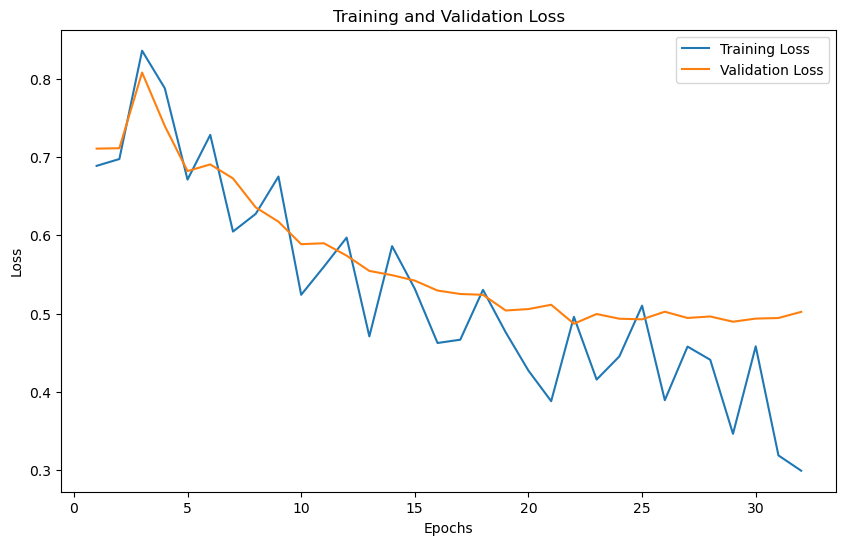

In [242]:
import matplotlib.pyplot as plt

#plots training and validation loss over epochs.
epochs = range(1, len(training_losses) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs, training_losses, label='Training Loss')
plt.plot(epochs, validation_losses, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


Calculate models evaluation. 

In [243]:
import torch
from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score
from torch.nn.functional import sigmoid

# Set the model to evaluation mode
model.eval()

# Containers for true labels and predictions
true_labels = []
predictions = []

# No gradient is needed for evaluation
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        # Forward pass
        outputs = model(inputs)
        
        # Convert logits to probabilities
        probs = sigmoid(outputs)
        
        # Store predictions and true labels
        predictions.append(probs.cpu().numpy())
        true_labels.append(labels.cpu().numpy())

# Concatenate all batches
true_labels = np.vstack(true_labels)
predictions = np.vstack(predictions)


In [244]:
binary_predictions = (predictions > 0.3).astype(int)

Calculate error metrics for each label separetly

In [245]:
from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score, average_precision_score

# Initialize scores dictionary
scores = {}

# Calculate scores for each label, adjusting the precision_score call
for i, label in enumerate(mlb.classes_):
    scores[label] = {
        'Recall': recall_score(true_labels[:, i], binary_predictions[:, i]),
        'Precision': precision_score(true_labels[:, i], binary_predictions[:, i], zero_division=0),  # Adjusted here
        'F1-Score': f1_score(true_labels[:, i], binary_predictions[:, i]),
        'ROC AUC': roc_auc_score(true_labels[:, i], predictions[:, i]),
        'Average Precision': average_precision_score(true_labels[:, i], predictions[:, i])
    }

# Print scores for each label
for label, metrics in scores.items():
    print(f"Label: {label}")
    for metric, score in metrics.items():
        print(f"{metric}: {score:.4f}")
    print()  # Newline for better readability


Label: CD
Recall: 0.7691
Precision: 0.5535
F1-Score: 0.6437
ROC AUC: 0.8763
Average Precision: 0.7706

Label: HYP
Recall: 0.7529
Precision: 0.3830
F1-Score: 0.5077
ROC AUC: 0.8675
Average Precision: 0.6045

Label: MI
Recall: 0.8228
Precision: 0.5963
F1-Score: 0.6915
ROC AUC: 0.8922
Average Precision: 0.7496

Label: NORM
Recall: 0.9450
Precision: 0.7437
F1-Score: 0.8323
ROC AUC: 0.9288
Average Precision: 0.9013

Label: STTC
Recall: 0.8356
Precision: 0.5796
F1-Score: 0.6844
ROC AUC: 0.9079
Average Precision: 0.7597



Evaluate model

In [246]:
def evaluate(model, data_loader, criterion, device):
    model.eval()
    total_loss = 0
    predictions = []
    actuals = []

    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            probabilities = torch.sigmoid(outputs)
            predicted = probabilities > 0.5
            predictions.append(predicted.cpu().numpy())
            actuals.append(labels.cpu().numpy())

    avg_loss = total_loss / len(data_loader)
    predictions = np.vstack(predictions)
    actuals = np.vstack(actuals)
    return avg_loss, predictions, actuals

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
test_loss, test_predictions, test_actuals = evaluate(model, test_loader, criterion, device)

Calculate confusion matrix for each label (I had difficulties using the normal SNS confusion matrix) 

In [247]:
from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score, average_precision_score, accuracy_score, hamming_loss, roc_curve

#true_labels = np.vstack(true_labels)
#predictions = np.vstack(predictions)

label_names = mlb.classes_ 
for i, label in enumerate(label_names):
    y_true = test_actuals.astype(int)[:, i]
    y_pred = test_predictions.astype(int)[:, i]

    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='binary')
    recall = recall_score(y_true, y_pred, average='binary')
    f1 = f1_score(y_true, y_pred, average='binary')
    auc_roc = roc_auc_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)

    print(f"{label} metrics:")
    print(f"Accuracy: {acc:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}, AUC-ROC: {auc_roc:.4f}")
    print("\n          Predicted")
    print("          0      1")
    print(f"Actual 0  {cm[0,0]}    {cm[0,1]}")
    print(f"       1  {cm[1,0]}    {cm[1,1]}\n")

CD metrics:
Accuracy: 0.8576, Precision: 0.6971, Recall: 0.6747, F1: 0.6857, AUC-ROC: 0.7935

          Predicted
          0      1
Actual 0  1519    146
       1  162    336

HYP metrics:
Accuracy: 0.8849, Precision: 0.5226, Recall: 0.6160, F1: 0.5654, AUC-ROC: 0.7690

          Predicted
          0      1
Actual 0  1752    148
       1  101    162

MI metrics:
Accuracy: 0.8308, Precision: 0.6604, Recall: 0.6962, F1: 0.6778, AUC-ROC: 0.7866

          Predicted
          0      1
Actual 0  1412    198
       1  168    385

NORM metrics:
Accuracy: 0.8474, Precision: 0.7871, Recall: 0.9015, F1: 0.8404, AUC-ROC: 0.8527

          Predicted
          0      1
Actual 0  964    235
       1  95    869

STTC metrics:
Accuracy: 0.8433, Precision: 0.6538, Recall: 0.7476, F1: 0.6976, AUC-ROC: 0.8107

          Predicted
          0      1
Actual 0  1433    207
       1  132    391



Display overall error score for the model (all labels combined)

In [249]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, hamming_loss, auc, roc_curve, roc_auc_score, confusion_matrix

accuracy = accuracy_score(test_actuals, test_predictions)
precision_micro = precision_score(test_actuals, test_predictions, average='micro')
recall_micro = recall_score(test_actuals, test_predictions, average='micro')
f1_micro = f1_score(test_actuals, test_predictions, average='micro')
hamming = hamming_loss(test_actuals, test_predictions)

fpr, tpr,_  = roc_curve(test_actuals.ravel(), test_predictions.ravel()) 
auc_roc = auc(fpr, tpr) 

print(f"Accuracy: {accuracy}")
print(f"Precision (Micro): {precision_micro}")
print(f"Recall (Micro): {recall_micro}")
print(f"F1 Score (Micro): {f1_micro}")
print(f"Hamming Loss: {hamming}")
print(f"Auc Roc: {auc_roc}")

Accuracy: 0.5501618122977346
Precision (Micro): 0.696457588560286
Recall (Micro): 0.7650838986076401
F1 Score (Micro): 0.7291595780877851
Hamming Loss: 0.14720295885344428
Auc Roc: 0.8242689270926895


Precision-recall curve for all labels separetly

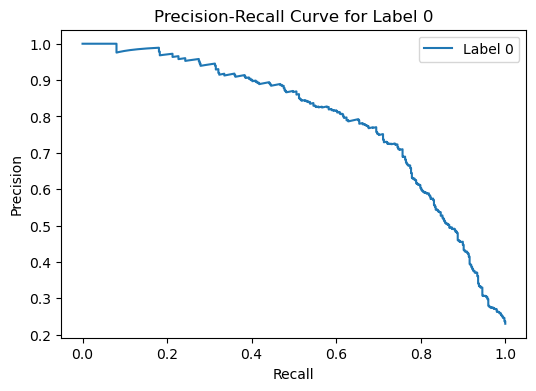

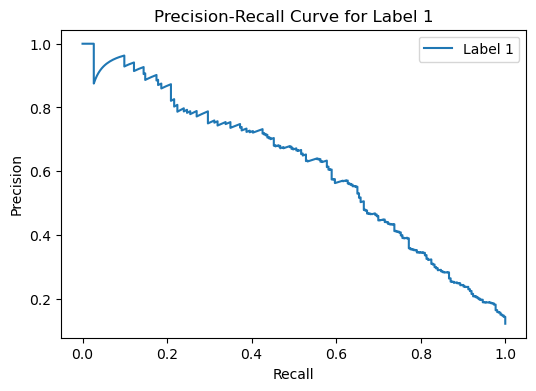

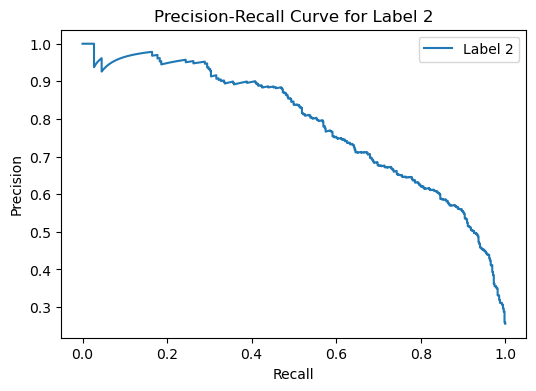

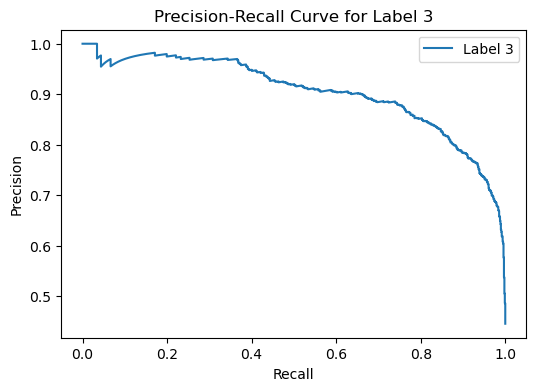

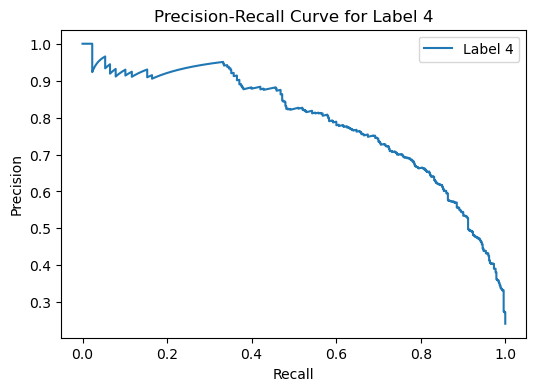

In [143]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# Assuming 'predictions' is a NumPy array of shape (num_samples, num_labels)
# and 'true_labels' is of the same shape
num_labels = predictions.shape[1]

for label_index in range(num_labels):
    # Extract the true labels and predictions for the current label
    true_labels_i = true_labels[:, label_index]
    predictions_i = predictions[:, label_index]

    # Compute precision-recall curve
    precision, recall, thresholds = precision_recall_curve(true_labels_i, predictions_i)

    # Plot the precision-recall curve for the current label
    plt.figure(figsize=(6, 4))
    plt.plot(recall, precision, label='Label {}'.format(label_index))
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve for Label {}'.format(label_index))
    plt.legend(loc="upper right")
    plt.show()


Overall accuracy of model 

In [219]:
model.eval()
with torch.no_grad():
    correct = 0
    total = 0
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        # Forward pass
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        
        # Ensure labels are in the correct shape for comparison
        if labels.ndim > 1:
            labels = labels.argmax(dim=1)
        
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f'Accuracy of the model on the test data: {accuracy:.2f}%')


Accuracy of the model on the test data: 42.16%
